In [11]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,RSI,RSI_Strategy,BB_SMA,BB_STD,Upper_Band,Lower_Band,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
1435,0.120949,0.122658,0.119667,0.122231,147347200,72.603176,0.0,0.113106,0.006235,0.119342,0.106871,NaN,NaN,0,NaN,NaN
1436,0.120949,0.121376,0.118385,0.120094,137782400,79.104933,-1.0,0.113235,0.006375,0.119609,0.106860,-1.0,-2.0,-1,0.000000,0.000000
1437,0.123940,0.124795,0.120521,0.120521,171315200,79.412181,-1.0,0.113598,0.006775,0.120373,0.106823,-1.0,-2.0,-1,0.024734,-0.024734
1438,0.122231,0.124368,0.122231,0.123513,194656000,74.648306,-1.0,0.114047,0.007043,0.121090,0.107003,-1.0,-2.0,-1,0.010600,-0.011282
1439,0.123940,0.125222,0.122658,0.122658,115718400,75.676126,-1.0,0.114431,0.007372,0.121804,0.107059,-1.0,-2.0,-1,0.024734,-0.025110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11398,257.459991,258.769989,254.369995,258.630005,41120000,51.916046,0.0,266.548999,6.492451,273.041450,260.056548,1.0,1.0,0,2127.669793,-0.830168
11399,259.880005,261.149994,253.679993,255.690002,38218500,44.758923,0.0,265.650000,6.075228,271.725228,259.574772,1.0,1.0,0,2147.678376,-0.830168
11400,260.829987,262.480011,256.950012,257.649994,30590800,45.445118,0.0,264.960500,5.778923,270.739422,259.181577,0.0,0.0,0,2155.532790,-0.830168
11401,260.809998,262.130005,259.549988,261.089996,26131800,50.329623,0.0,264.317000,5.464904,269.781903,258.852096,0.0,0.0,0,2155.367521,-0.830168


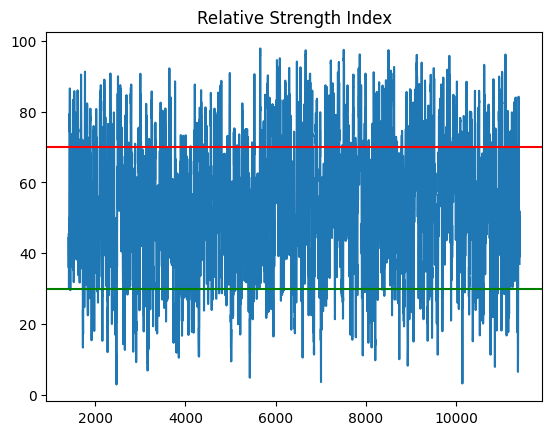

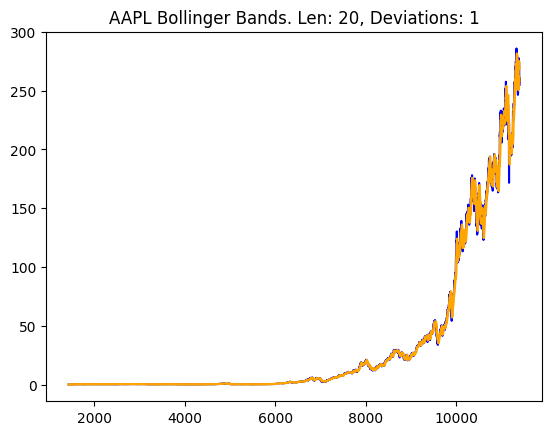

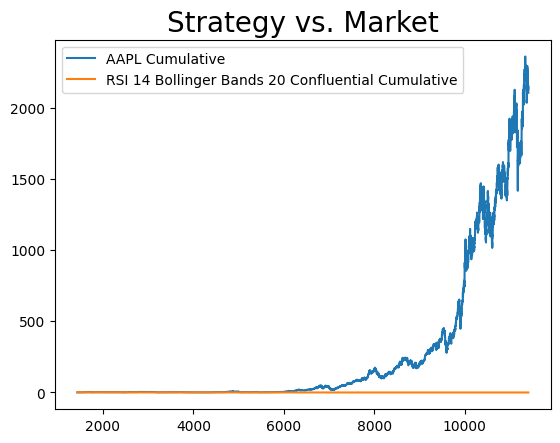

In [ ]:
TICKER = 'AAPL'
INTERVAL='1d'

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

BB_LEN = 20
DEVS = 1
RSI_LENGTH = 14
RSI_OVERBOUGHT = 70
RSI_OVERSOLD = 30

# what subsetion of that data are you interested in
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

def add_RSI(df, length=RSI_LENGTH, overbought=RSI_OVERBOUGHT, oversold=RSI_OVERSOLD):

    price_change = df['Close'].diff()
    
    # separate gains/losses
    gain = price_change.where(price_change > 0, 0)
    loss = -price_change.where(price_change < 0, 0)

    # average gain vs loss
    avg_gain = gain.rolling(window=length).mean()
    avg_loss = loss.rolling(window=length).mean()

    # calculate rsi
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    df['RSI'] = rsi

    # plot the relative strength index
    plt.plot(df['RSI'])
    plt.axhline(overbought, color='red')
    plt.axhline(oversold, color='green')
    plt.title('Relative Strength Index')

    return df.dropna()

def add_RSI_strategy(df, overbought=RSI_OVERBOUGHT, oversold=RSI_OVERSOLD):

    df['RSI_Strategy'] = 0
    df['RSI_Strategy'] = np.where(df['RSI'] > overbought, -1, 
                     np.where(df['RSI'] < oversold, 1, 0))
    
    # shift back to make sure we have seen the signal
    df['RSI_Strategy'] = df['RSI_Strategy'].shift(1)
    return df

def add_BB(df, devs=DEVS, bb_len=BB_LEN):

    # can change to ema (use MACD video/code for reference)
    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    # get the standard deviation of the close prices for the period
    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], -1, 
        np.where(df['Close'] < df['Lower_Band'], 1, 0)
        )
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df

def add_full_strategy(df):

    df['Full_Strategy'] = df['RSI_Strategy'] + df['BB_Strategy']

    # adjust values for simplicity
    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 3, 
                     np.where(df['Full_Strategy'] == -2, -3, 0))

    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'RSI {RSI_LENGTH} Bollinger Bands {BB_LEN} Confluential Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_RSI(df)
    df = add_RSI_strategy(df)
    df = add_BB(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df

df = main()

df